# 05 — Link prediction with Node2Vec

Trains Node2Vec embeddings on the Hetionet Compound–Gene–Disease subgraph and compares link-prediction performance against the spectral and heuristic baselines from `04_link_prediction.ipynb` on the **identical** pair universe and train/test split.

**Design decisions** (see `CLAUDE.md` and project README for rationale):
- Walks are restricted to the **Compound∪Gene∪Disease induced subgraph** to avoid the random walker getting trapped in the much larger Gene-anatomy-side regions of the full graph.
- **Top-degree Gene hubs are removed** before walking (hub correction is mandatory in this project).
- **Test CtD edges are dropped** from the graph before walking — same leakage discipline as nb4.
- Three scoring functions are reported per embedding: **Hadamard + LR** (paper-canonical), **Concat + LR** (matches nb4's spectral feature), **Cosine** (unsupervised parity with nb4 spectral cosine).
- Evaluation: AUROC + AUPRC with **bootstrap 95% CI** on the locked test set.
- Embeddings visualised with PCA, t-SNE, UMAP; outliers identified in full-dim space, then located on the 2D map.

## 1. Setup

In [1]:
from __future__ import annotations
import json, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path('artifacts')
CACHE = pathlib.Path('cache/node2vec'); CACHE.mkdir(parents=True, exist_ok=True)
assert ART.exists(), 'Run nb4 to the end first — it writes artifacts/.'

## 2. Load the locked split + baseline scores
We **do not re-split.** Anything stochastic uses `SEED = meta['split_seed']`.

In [2]:
meta = json.loads((ART / 'splits' / 'split_meta.json').read_text())
pairs = pd.read_parquet(ART / 'splits' / 'pairs.parquet')
split = np.load(ART / 'splits' / 'lr_split.npz')
idx_train, idx_test = split['idx_train'], split['idx_test']
baseline = pd.read_parquet(ART / 'predictions' / 'baseline_spectral.parquet')

SEED = meta['split_seed']
rng  = np.random.default_rng(SEED)
y = pairs['y'].to_numpy()

test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
pos_mask  = y == 1
test_positives  = pairs.loc[pos_mask &  test_mask, ['compound', 'disease']]
train_positives = pairs.loc[pos_mask & ~test_mask, ['compound', 'disease']]

print(f'Pairs: {len(pairs):,} | positives: {int(y.sum())} | '
      f'train: {len(idx_train):,} | test: {len(idx_test):,} | seed: {SEED}')
print(f'Train positives (kept in graph) : {len(train_positives)}')
print(f'Test  positives (dropped, leakage prevention): {len(test_positives)}')

Pairs: 206,312 | positives: 755 | train: 165,049 | test: 41,263 | seed: 42
Train positives (kept in graph) : 604
Test  positives (dropped, leakage prevention): 151


## 3. Build the walk graph
Steps: (a) load Hetionet, (b) induce on Compound∪Gene∪Disease, (c) drop test CtD edges, (d) drop top-`HUB_K` Gene hubs by degree.

In [3]:
HUB_K = 20  # drop top-K Gene hubs by degree (e.g. UBC has betweenness 0.34)
KEEP_KINDS = {'Compound', 'Gene', 'Disease'}

t0 = time.time()
hetnet = load_hetnet()
print(f'Loaded hetnet in {time.time()-t0:.1f}s')

# Undirected simple graph keyed by (kind, identifier)
G = nx.Graph()
for n in hetnet['nodes']:
    if n['kind'] in KEEP_KINDS:
        G.add_node((n['kind'], n['identifier']), kind=n['kind'], name=n['name'])
kept = set(G.nodes())
for e in hetnet['edges']:
    u = tuple(e['source_id']); v = tuple(e['target_id'])
    if u in kept and v in kept:
        G.add_edge(u, v, kind=e['kind'])
print(f'C∪G∪D subgraph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

# Drop test CtD edges
dropped = 0
for c, d in test_positives.itertuples(index=False):
    u, v = ('Compound', c), ('Disease', d)
    if G.has_edge(u, v):
        G.remove_edge(u, v); dropped += 1
print(f'Dropped {dropped} test CtD edges')

# Hub correction: remove top-HUB_K Gene nodes by degree
gene_deg = sorted(
    ((n, deg) for n, deg in G.degree() if n[0] == 'Gene'),
    key=lambda x: -x[1])
hubs = [n for n, _ in gene_deg[:HUB_K]]
print('Removing Gene hubs:')
for n, deg in gene_deg[:HUB_K]:
    print(f"  {G.nodes[n]['name']!s:30s}  degree={deg}")
G.remove_nodes_from(hubs)

# Restrict to the largest connected component (node2vec needs connectivity)
lcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc_nodes).copy()
print(f'Walk graph (post-hub, LCC): {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

# Coverage check vs locked pair universe
compound_nodes_in_G = {n[1] for n in G.nodes if n[0] == 'Compound'}
disease_nodes_in_G  = {n[1] for n in G.nodes if n[0] == 'Disease'}
covered = pairs['compound'].isin(compound_nodes_in_G) & pairs['disease'].isin(disease_nodes_in_G)
print(f'Pair-universe coverage: {covered.mean():.1%} ({covered.sum()} / {len(pairs)})')
print(f'Test-set coverage    : {covered[idx_test].mean():.1%}')
if not covered.all():
    print('NOTE: uncovered pairs will be assigned score 0 in evaluation.')

Loaded hetnet in 10.8s


C∪G∪D subgraph: 22,634 nodes, 558,284 edges
Dropped 151 test CtD edges
Removing Gene hubs:
  UBC                             degree=8655
  APP                             degree=1976
  RPS4Y1                          degree=1843
  PCNA                            degree=1833
  CDC20                           degree=1813
  MCOLN1                          degree=1363
  NME1                            degree=1350
  STUB1                           degree=1223
  TIMM9                           degree=1192
  MIF                             degree=1162
  PUF60                           degree=1148
  CSRP1                           degree=1143
  SUMO2                           degree=1135
  MAL                             degree=1120
  CUL3                            degree=1073
  TYMS                            degree=1051
  GRB2                            degree=1019
  SATB1                           degree=986
  CES1                            degree=975
  DLD                             deg

Walk graph (post-hub, LCC): 19,683 nodes, 525,174 edges
Pair-universe coverage: 100.0% (206312 / 206312)
Test-set coverage    : 100.0%


## 4. Train Node2Vec
Runs **one** configuration end-to-end as the headline result; a sweep template is provided as a follow-up cell — uncomment to explore (each config takes ~5–15 min on this graph).

Hyperparameters reported here:
- `d = 64` (standard; a `d = 4` control to match nb4's spectral is in the sweep)
- `walk_length = 40`, `num_walks = 10` (paper defaults are 80×10; halved here for runtime)
- `p = 1, q = 1` (DeepWalk-equivalent baseline; vary in sweep)
- `window = 10`, `min_count = 1`

In [4]:
from node2vec import Node2Vec

def train_node2vec(G, *, d, p, q, walk_length=40, num_walks=10, window=10, seed=SEED, workers=4):
    key = f'd{d}_p{p}_q{q}_wl{walk_length}_nw{num_walks}_w{window}_seed{seed}'
    cache_file = CACHE / f'{key}.pkl'
    if cache_file.exists():
        print(f'[cache] loading {key}')
        with open(cache_file, 'rb') as f:
            return pickle.load(f), key
    print(f'[train] {key}')
    t0 = time.time()
    n2v = Node2Vec(G, dimensions=d, walk_length=walk_length, num_walks=num_walks,
                   p=p, q=q, workers=workers, seed=seed, quiet=True)
    model = n2v.fit(window=window, min_count=1, seed=seed, workers=workers)
    emb = {n: model.wv[str(n)] for n in G.nodes()}
    print(f'        done in {time.time()-t0:.1f}s, {len(emb)} embeddings')
    with open(cache_file, 'wb') as f:
        pickle.dump(emb, f)
    return emb, key

emb, run_key = train_node2vec(G, d=64, p=1, q=1)
print(f'Run key: {run_key}')

[cache] loading d64_p1_q1_wl40_nw10_w10_seed42
Run key: d64_p1_q1_wl40_nw10_w10_seed42


### 4b. (optional) Hyperparameter sweep — uncomment to run

In [5]:
# sweep_configs = [
#     dict(d=4,  p=1, q=1),    # dim-control vs nb4 spectral (d=4)
#     dict(d=64, p=1, q=1),    # already trained above
#     dict(d=64, p=1, q=0.5),  # DFS-biased — explore distant communities
#     dict(d=64, p=1, q=2.0),  # BFS-biased — local structure
# ]
# sweep_embs = {}
# for cfg in sweep_configs:
#     emb_i, key_i = train_node2vec(G, **cfg)
#     sweep_embs[key_i] = emb_i

## 5. Pair scoring
Three scoring schemes on the locked pair universe:
- **Hadamard + LR**: paper-canonical (Grover & Leskovec 2016, Table 1)
- **Concat + LR**: matches nb4's spectral logistic-regression setup
- **Cosine**: unsupervised, parity with nb4's spectral cosine

In [6]:
def build_pair_features(pairs_df, emb, op):
    """op ∈ {'hadamard', 'concat'}. Pairs with a missing node get a zero feature row."""
    d = len(next(iter(emb.values())))
    out_dim = d if op == 'hadamard' else 2 * d
    X = np.zeros((len(pairs_df), out_dim), dtype=np.float32)
    have = np.zeros(len(pairs_df), dtype=bool)
    for i, (c, dd) in enumerate(zip(pairs_df['compound'].to_numpy(),
                                    pairs_df['disease'].to_numpy())):
        u, v = ('Compound', c), ('Disease', dd)
        if u in emb and v in emb:
            eu, ev = emb[u], emb[v]
            X[i] = eu * ev if op == 'hadamard' else np.concatenate([eu, ev])
            have[i] = True
    return X, have

X_had,    have = build_pair_features(pairs, emb, 'hadamard')
X_concat, _    = build_pair_features(pairs, emb, 'concat')
print(f'Pairs with both endpoints embedded: {have.mean():.1%}')

def score_lr(X, y, idx_train, idx_test, seed=SEED):
    clf = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=seed)
    clf.fit(X[idx_train], y[idx_train])
    return clf.predict_proba(X)[:, 1]

score_had    = score_lr(X_had,    y, idx_train, idx_test)
score_concat = score_lr(X_concat, y, idx_train, idx_test)

# Cosine (unsupervised) — only defined where both endpoints have embeddings
norms = {n: e / (np.linalg.norm(e) + 1e-12) for n, e in emb.items()}
score_cos = np.zeros(len(pairs))
for i, (c, dd) in enumerate(zip(pairs['compound'].to_numpy(),
                                pairs['disease'].to_numpy())):
    u, v = ('Compound', c), ('Disease', dd)
    if u in norms and v in norms:
        score_cos[i] = float(norms[u] @ norms[v])

Pairs with both endpoints embedded: 100.0%


## 6. Evaluation on the locked test set (with bootstrap 95% CI)
Bootstrap over the **test set** (B=500) gives a CI on AUROC and AUPRC. With only ~151 test positives the AUPRC variance is large — point estimates alone are misleading.

In [7]:
def bootstrap_metric(y_true, y_score, metric, B=500, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        if y_true[idx].sum() == 0:
            stats[b] = np.nan
            continue
        stats[b] = metric(y_true[idx], y_score[idx])
    stats = stats[~np.isnan(stats)]
    return float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))

def eval_row(name, score, idx=idx_test):
    y_t = y[idx]; s = score[idx]
    auroc = roc_auc_score(y_t, s)
    auprc = average_precision_score(y_t, s)
    lo_roc, hi_roc = bootstrap_metric(y_t, s, roc_auc_score)
    lo_pr,  hi_pr  = bootstrap_metric(y_t, s, average_precision_score)
    return {'method': name, 'AUROC': auroc, 'AUROC_lo': lo_roc, 'AUROC_hi': hi_roc,
            'AUPRC': auprc, 'AUPRC_lo': lo_pr,  'AUPRC_hi': hi_pr}

results = pd.DataFrame([
    eval_row('node2vec + Hadamard + LR', score_had),
    eval_row('node2vec + Concat   + LR', score_concat),
    eval_row('node2vec + Cosine',         score_cos),
    eval_row('spectral + Concat   + LR (nb4)', baseline['score_lr_spectral'].to_numpy()),
    eval_row('spectral + Cosine        (nb4)', baseline['score_cos_spectral'].to_numpy()),
])
results['AUROC_str'] = results.apply(lambda r: f"{r.AUROC:.3f}  [{r.AUROC_lo:.3f}, {r.AUROC_hi:.3f}]", axis=1)
results['AUPRC_str'] = results.apply(lambda r: f"{r.AUPRC:.4f} [{r.AUPRC_lo:.4f}, {r.AUPRC_hi:.4f}]", axis=1)
results[['method', 'AUROC_str', 'AUPRC_str']]

,method,AUROC_str,AUPRC_str
0,node2vec + Hadamard + LR,"0.859 [0.837, 0.882]","0.0227 [0.0161, 0.0340]"
1,node2vec + Concat + LR,"0.921 [0.904, 0.936]","0.0310 [0.0251, 0.0402]"
2,node2vec + Cosine,"0.781 [0.737, 0.817]","0.0176 [0.0131, 0.0244]"
3,spectral + Concat + LR (nb4),"0.681 [0.631, 0.725]","0.0097 [0.0060, 0.0242]"
4,spectral + Cosine (nb4),"0.622 [0.572, 0.672]","0.0058 [0.0047, 0.0078]"


### 6b. ROC + PR overlay on test set

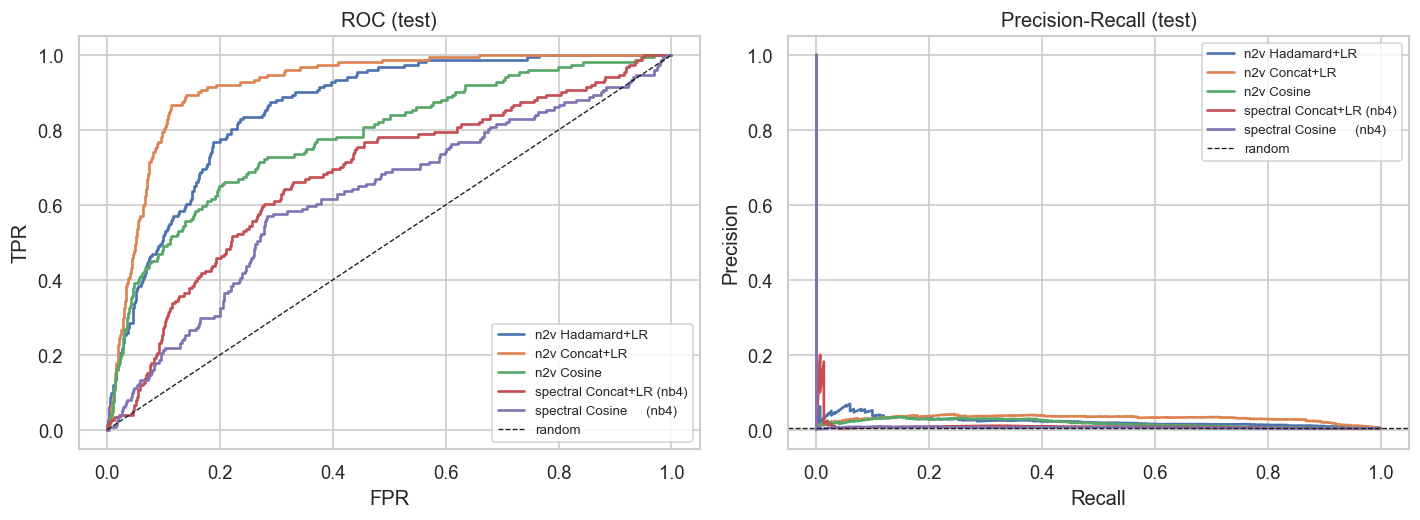

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
to_plot = [
    ('n2v Hadamard+LR',  score_had,     'C0'),
    ('n2v Concat+LR',    score_concat,  'C1'),
    ('n2v Cosine',       score_cos,     'C2'),
    ('spectral Concat+LR (nb4)', baseline['score_lr_spectral'].to_numpy(),  'C3'),
    ('spectral Cosine     (nb4)', baseline['score_cos_spectral'].to_numpy(), 'C4'),
]
for name, s, color in to_plot:
    fpr, tpr, _ = roc_curve(y[idx_test], s[idx_test])
    axes[0].plot(fpr, tpr, label=name, color=color, lw=1.6)
    prec, rec, _ = precision_recall_curve(y[idx_test], s[idx_test])
    axes[1].plot(rec, prec, label=name, color=color, lw=1.6)
axes[0].plot([0,1],[0,1], 'k--', lw=0.8, label='random')
axes[0].set(title='ROC (test)', xlabel='FPR', ylabel='TPR'); axes[0].legend(fontsize=8)
axes[1].axhline(y[idx_test].mean(), color='k', ls='--', lw=0.8, label='random')
axes[1].set(title='Precision-Recall (test)', xlabel='Recall', ylabel='Precision'); axes[1].legend(fontsize=8)
plt.tight_layout()

## 7. Embedding visualisation
Three projections — PCA (global linear structure), t-SNE (local clusters), UMAP (compromise). Coloured by node kind.

In [9]:
nodes_emb = list(emb.keys())
M = np.stack([emb[n] for n in nodes_emb])
kinds = np.array([n[0] for n in nodes_emb])
names = np.array([G.nodes[n]['name'] for n in nodes_emb])

print(f'Embedding matrix: {M.shape}  | kinds:', dict(zip(*np.unique(kinds, return_counts=True))))

pca_xy = PCA(n_components=2, random_state=SEED).fit_transform(M)
print('PCA done')
tsne_xy = TSNE(n_components=2, random_state=SEED, init='pca', perplexity=30, max_iter=750).fit_transform(M)
print('t-SNE done')
try:
    import umap
    umap_xy = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1).fit_transform(M)
    print('UMAP done')
except Exception as e:
    print('UMAP skipped:', e)
    umap_xy = None

Embedding matrix: (19683, 64)  | kinds: {'Compound': 1517, 'Disease': 136, 'Gene': 18030}
PCA done


t-SNE done


/Users/zhangchengru/Documents/hetionet-eda/eda/.pixi/envs/default/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done


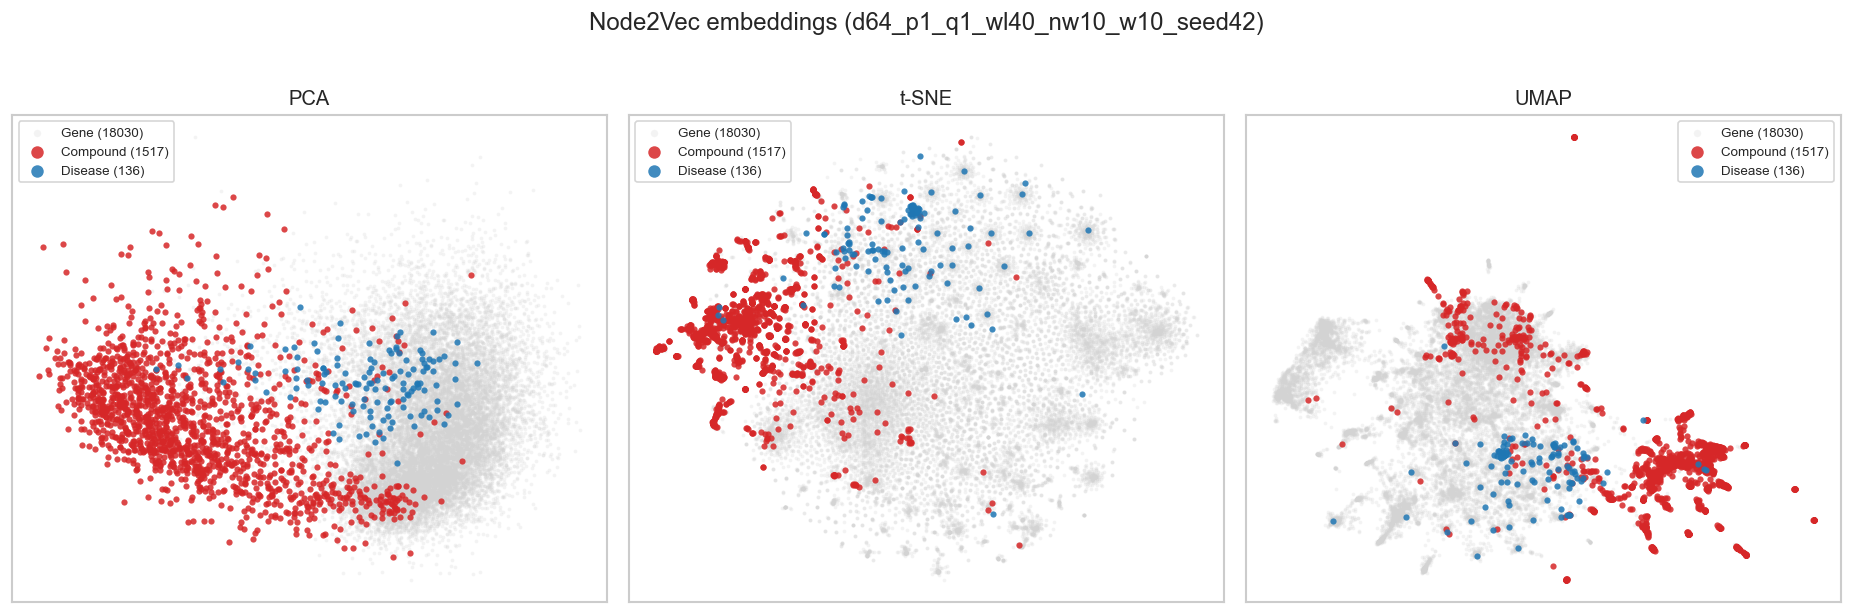

In [10]:
color_map = {'Compound': 'tab:red', 'Disease': 'tab:blue', 'Gene': 'lightgray'}
alpha_map = {'Compound': 0.85,      'Disease': 0.85,        'Gene': 0.25}
size_map  = {'Compound': 14,        'Disease': 14,          'Gene': 5}

def scatter_by_kind(ax, xy, title):
    for k in ['Gene', 'Compound', 'Disease']:  # Genes underneath
        m = kinds == k
        ax.scatter(xy[m, 0], xy[m, 1], s=size_map[k], c=color_map[k],
                   alpha=alpha_map[k], label=f'{k} ({m.sum()})', linewidths=0)
    ax.set_title(title); ax.legend(fontsize=8, markerscale=2)
    ax.set_xticks([]); ax.set_yticks([])

n_panels = 3 if umap_xy is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5.2*n_panels, 5))
scatter_by_kind(axes[0], pca_xy,  'PCA')
scatter_by_kind(axes[1], tsne_xy, 't-SNE')
if umap_xy is not None:
    scatter_by_kind(axes[2], umap_xy, 'UMAP')
plt.suptitle(f'Node2Vec embeddings ({run_key})', y=1.02)
plt.tight_layout()

### 7b. Outliers in full-dimensional space
2D projections distort distances, so the 'outlier' question must be answered in full-dim space first, then visualised. Definition: top-K nodes farthest from the per-kind centroid by Euclidean distance.

In [11]:
K_OUTLIERS = 10
outlier_idx = []
for k in ['Compound', 'Disease', 'Gene']:
    m = np.where(kinds == k)[0]
    centroid = M[m].mean(axis=0)
    dists = np.linalg.norm(M[m] - centroid, axis=1)
    top = m[np.argsort(-dists)[:K_OUTLIERS]]
    outlier_idx.extend(top.tolist())

outlier_df = pd.DataFrame({
    'kind': kinds[outlier_idx],
    'name': names[outlier_idx],
    'identifier': [nodes_emb[i][1] for i in outlier_idx],
    'degree_in_walk_graph': [G.degree(nodes_emb[i]) for i in outlier_idx],
    'pca_x':   pca_xy[outlier_idx, 0],
    'pca_y':   pca_xy[outlier_idx, 1],
    'tsne_x':  tsne_xy[outlier_idx, 0],
    'tsne_y':  tsne_xy[outlier_idx, 1],
})
outlier_df

,kind,name,identifier,degree_in_walk_graph,pca_x,pca_y,tsne_x,tsne_y
0,Compound,Oritavancin,DB04911,2,-2.202020,1.386940,-71.736519,5.060795
1,Compound,Telavancin,DB06402,2,-2.335418,1.361573,-71.723526,5.071474
2,Compound,Amikacin,DB00479,9,-1.155180,0.318362,-40.316257,5.743553
3,Compound,Nafarelin,DB00666,9,-1.173864,1.660532,-32.806202,47.838665
4,Compound,Framycetin,DB00452,8,-0.756092,0.052802,-40.305660,5.730849
5,Compound,Cetrorelix,DB00050,7,-0.777138,1.497622,-32.829510,47.892483
6,Compound,Neomycin,DB00994,7,-0.899285,0.044246,-40.306728,5.732924
7,Compound,L-Serine,DB00133,26,-0.769792,0.395047,-37.963654,27.522799
8,Compound,Gonadorelin,DB00644,10,-1.336567,1.383154,-32.782990,47.784256
9,Compound,Tobramycin,DB00684,8,-1.020881,0.421198,-40.310978,5.741375


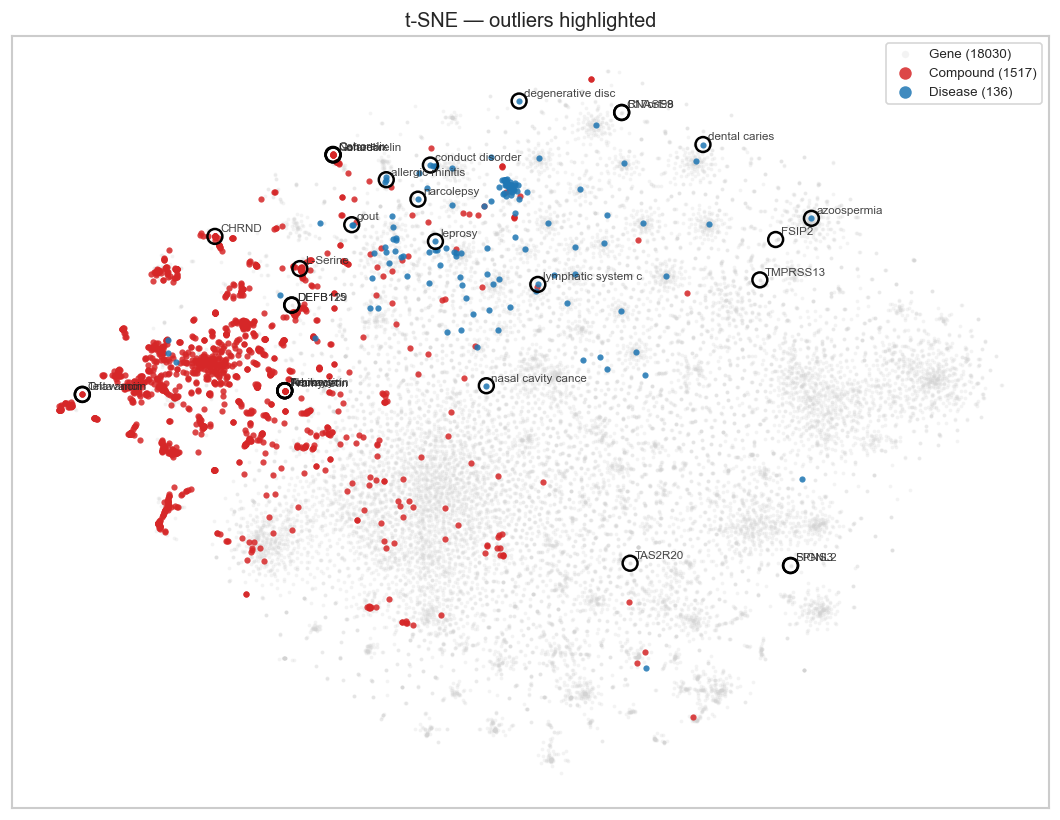

In [12]:
# Locate outliers on the t-SNE map (most visually informative usually)
fig, ax = plt.subplots(figsize=(9, 7))
scatter_by_kind(ax, tsne_xy, 't-SNE — outliers highlighted')
ax.scatter(tsne_xy[outlier_idx, 0], tsne_xy[outlier_idx, 1],
           s=80, facecolors='none', edgecolors='black', linewidths=1.5, label='outliers')
for i in outlier_idx:
    ax.annotate(names[i][:18], (tsne_xy[i, 0], tsne_xy[i, 1]),
                fontsize=7, alpha=0.85, xytext=(3, 3), textcoords='offset points')
plt.tight_layout()

### 7c. Do known CtD pairs embed closer than random pairs?
If Node2Vec captures CtD-relevant structure, known treatment pairs should have **shorter** embedding distance than matched random (compound, disease) pairs. This is more diagnostic than looking at outliers.

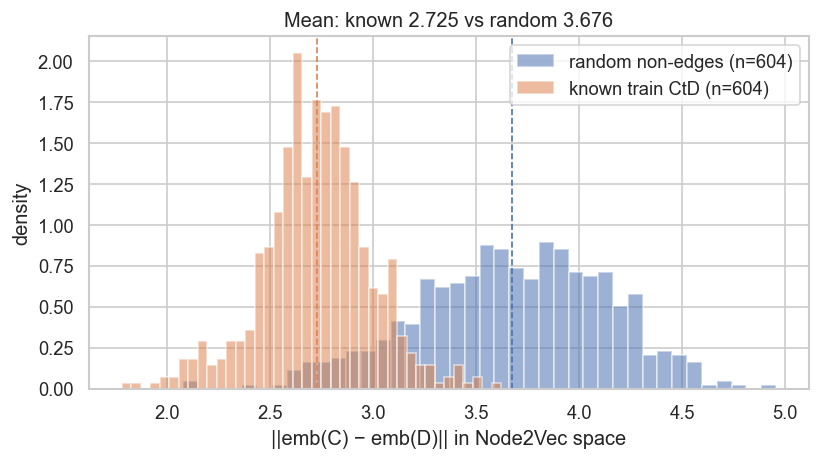

In [13]:
compound_idx_in_emb = {n[1]: i for i, n in enumerate(nodes_emb) if n[0] == 'Compound'}
disease_idx_in_emb  = {n[1]: i for i, n in enumerate(nodes_emb) if n[0] == 'Disease'}

def pair_dist(c, dd):
    if c in compound_idx_in_emb and dd in disease_idx_in_emb:
        return float(np.linalg.norm(M[compound_idx_in_emb[c]] - M[disease_idx_in_emb[dd]]))
    return np.nan

# Train positives only (test positives were removed from G)
known_dists = np.array([pair_dist(c, d) for c, d in train_positives.itertuples(index=False)])
known_dists = known_dists[~np.isnan(known_dists)]

# Random non-edge pairs, sampled to same size
rng2 = np.random.default_rng(SEED)
neg_pairs = pairs.loc[~pos_mask, ['compound', 'disease']].sample(
    n=min(len(known_dists), int((~pos_mask).sum())), random_state=SEED)
rand_dists = np.array([pair_dist(c, d) for c, d in neg_pairs.itertuples(index=False)])
rand_dists = rand_dists[~np.isnan(rand_dists)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rand_dists,  bins=40, alpha=0.55, label=f'random non-edges (n={len(rand_dists)})', density=True)
ax.hist(known_dists, bins=40, alpha=0.55, label=f'known train CtD (n={len(known_dists)})', density=True)
ax.axvline(known_dists.mean(), color='C1', ls='--', lw=1)
ax.axvline(rand_dists.mean(),  color='C0', ls='--', lw=1)
ax.set(xlabel='||emb(C) − emb(D)|| in Node2Vec space', ylabel='density',
       title=f'Mean: known {known_dists.mean():.3f} vs random {rand_dists.mean():.3f}')
ax.legend()
plt.tight_layout()

## 8. Error analysis: where do node2vec and spectral disagree?
Looks at test-set pairs ranked highly by one method but not the other. Use the strongest scoring scheme per method (Hadamard+LR for node2vec, Concat+LR for spectral).

In [14]:
test_view = pairs.iloc[idx_test].copy()
test_view['score_n2v']      = score_had[idx_test]
test_view['score_spectral'] = baseline['score_lr_spectral'].to_numpy()[idx_test]
test_view['rank_n2v']       = test_view['score_n2v'].rank(ascending=False)
test_view['rank_spectral']  = test_view['score_spectral'].rank(ascending=False)
test_view['rank_diff']      = test_view['rank_spectral'] - test_view['rank_n2v']  # +ve = n2v better

name_lookup = {(n[0], n[1]): G.nodes[n]['name'] for n in G.nodes()}
test_view['compound_name'] = [name_lookup.get(('Compound', c), c) for c in test_view['compound']]
test_view['disease_name']  = [name_lookup.get(('Disease',  d), d) for d in test_view['disease']]

print('=== Test positives node2vec ranks much higher than spectral ===')
wins = test_view[test_view['y'] == 1].nlargest(10, 'rank_diff')
print(wins[['compound_name', 'disease_name', 'rank_n2v', 'rank_spectral', 'score_n2v', 'score_spectral']].to_string(index=False))

print('\n=== Test positives spectral ranks much higher than node2vec ===')
losses = test_view[test_view['y'] == 1].nsmallest(10, 'rank_diff')
print(losses[['compound_name', 'disease_name', 'rank_n2v', 'rank_spectral', 'score_n2v', 'score_spectral']].to_string(index=False))

=== Test positives node2vec ranks much higher than spectral ===
     compound_name                       disease_name  rank_n2v  rank_spectral  score_n2v  score_spectral
         Cisplatin                        lung cancer     630.0        39139.0   0.949718        0.347837
         Cisplatin                        bone cancer     240.0        37950.0   0.981931        0.360095
        Prednisone             ankylosing spondylitis    1610.0        39288.0   0.867794        0.345714
      Prednisolone             ankylosing spondylitis    2210.0        38743.0   0.816120        0.353300
      Sulfadiazine                            malaria     470.0        36386.0   0.964237        0.365781
        Saquinavir acquired immunodeficiency syndrome    3654.0        38136.0   0.708089        0.359139
Methylprednisolone             ankylosing spondylitis    3672.0        37986.0   0.706775        0.359958
        Carmustine                       brain cancer     289.0        33594.0   0.97803

## 9. Persist this method's predictions

In [15]:
out = pairs[['compound', 'disease', 'y']].copy()
out['score_n2v_hadamard'] = score_had
out['score_n2v_concat']   = score_concat
out['score_n2v_cosine']   = score_cos
out['in_test']            = test_mask
out.to_parquet(ART / 'predictions' / 'node2vec.parquet')

method_meta = {
    'method': 'node2vec',
    'library': 'eliorc/node2vec (gensim Word2Vec)',
    'run_key': run_key,
    'walk_graph': {
        'kinds_kept': sorted(KEEP_KINDS),
        'hub_K_removed': HUB_K,
        'n_nodes_post_hub_lcc': G.number_of_nodes(),
        'n_edges_post_hub_lcc': G.number_of_edges(),
        'test_ctd_edges_removed': int(dropped),
    },
    'results': results.drop(columns=['AUROC_str', 'AUPRC_str']).to_dict(orient='records'),
    'split_meta_ref': str(ART / 'splits' / 'split_meta.json'),
}
(ART / 'predictions' / 'node2vec_meta.json').write_text(json.dumps(method_meta, indent=2, default=str))
print('Saved:')
print(f"  {ART / 'predictions' / 'node2vec.parquet'}")
print(f"  {ART / 'predictions' / 'node2vec_meta.json'}")

Saved:
  artifacts/predictions/node2vec.parquet
  artifacts/predictions/node2vec_meta.json
